In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from xhistogram.xarray import histogram as xhist
import dask
from dask.distributed import Client, LocalCluster
import os

In [2]:
ds = xr.open_dataset(
    "../data/SV_heatmap_2025.zarr",
    engine="zarr",
    chunks={"release_date": 1, "trajectory": -1, "obs": -1},
)

# Keep only what you need for a lon/lat heatmap — pid_orig, time, z are dead weight
ds = ds[["lon", "lat"]]
ds

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


<xarray.Dataset> Size: 32GB
Dimensions:       (release_date: 73, trajectory: 230656, obs: 240)
Coordinates:
  * obs           (obs) int32 960B 0 1 2 3 4 5 6 ... 233 234 235 236 237 238 239
  * release_date  (release_date) datetime64[ns] 584B 2025-01-01 ... 2025-12-27
  * trajectory    (trajectory) int64 2MB 0 1 2 3 ... 230652 230653 230654 230655
Data variables:
    lon           (release_date, trajectory, obs) float32 16GB dask.array<chunksize=(1, 230656, 240), meta=np.ndarray>
    lat           (release_date, trajectory, obs) float32 16GB dask.array<chunksize=(1, 230656, 240), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SVParticleAdvectionRK4CheckOutOfBoundsCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [3]:
lon_min, lon_max, lat_min, lat_max = dask.compute(
    ds.lon.min(), ds.lon.max(), ds.lat.min(), ds.lat.max()
)
print(f"lon: {lon_min:.3f} to {lon_max:.3f}")
print(f"lat: {lat_min:.3f} to {lat_max:.3f}")

lon: -27.134 to -23.679
lat: 15.419 to 17.798


In [4]:
bin_width = 0.01  # start coarse (~5 km); tighten later only if you actually need finer detail

lon_bins = np.arange(lon_min, lon_max + bin_width, bin_width)
lat_bins = np.arange(lat_min, lat_max + bin_width, bin_width)

n_lon = len(lon_bins) - 1
n_lat = len(lat_bins) - 1
n_release = ds.sizes["release_date"]
n_obs = ds.sizes["obs"]

size_gb = n_release * n_obs * n_lon * n_lat * 8 / 1e9
print(f"grid: {n_lon} x {n_lat} bins")
print(f"full histogram size estimate: {size_gb:.2f} GB")

grid: 346 x 238 bins
full histogram size estimate: 11.54 GB


In [5]:
out_path = "../data/SV_heatmap_2025_binned.zarr"

for i, rd in enumerate(ds.release_date.values):
    sub = ds.sel(release_date=rd)

    hist = xhist(
        sub.lon, sub.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory"],
        bin_dim_suffix="",
    ).compute()

    # fail fast if binning collapses to 1 bin again, instead of finding out 73 iterations later
    assert hist.sizes["lon"] == n_lon and hist.sizes["lat"] == n_lat, hist.sizes

    hist = hist.expand_dims(release_date=[rd]).to_dataset(name="histogram_lon_lat")

    if i == 0:
        hist.to_zarr(out_path, mode="w")
    else:
        hist.to_zarr(out_path, mode="a", append_dim="release_date")

    del sub, hist
    print(f"done {rd}  ({i+1}/{n_release})")

done 2025-01-01T00:00:00.000000000  (1/73)
done 2025-01-06T00:00:00.000000000  (2/73)
done 2025-01-11T00:00:00.000000000  (3/73)
done 2025-01-16T00:00:00.000000000  (4/73)
done 2025-01-21T00:00:00.000000000  (5/73)
done 2025-01-26T00:00:00.000000000  (6/73)
done 2025-01-31T00:00:00.000000000  (7/73)
done 2025-02-05T00:00:00.000000000  (8/73)
done 2025-02-10T00:00:00.000000000  (9/73)
done 2025-02-15T00:00:00.000000000  (10/73)
done 2025-02-20T00:00:00.000000000  (11/73)
done 2025-02-25T00:00:00.000000000  (12/73)
done 2025-03-02T00:00:00.000000000  (13/73)
done 2025-03-07T00:00:00.000000000  (14/73)
done 2025-03-12T00:00:00.000000000  (15/73)
done 2025-03-17T00:00:00.000000000  (16/73)
done 2025-03-22T00:00:00.000000000  (17/73)
done 2025-03-27T00:00:00.000000000  (18/73)
done 2025-04-01T00:00:00.000000000  (19/73)
done 2025-04-06T00:00:00.000000000  (20/73)
done 2025-04-11T00:00:00.000000000  (21/73)
done 2025-04-16T00:00:00.000000000  (22/73)
done 2025-04-21T00:00:00.000000000  (23/7

In [9]:
ds_heatmap_2025 = xr.open_dataset("../data/SV_heatmap_2025_binned.zarr", engine="zarr")
ds_heatmap_2025

<xarray.Dataset> Size: 12GB
Dimensions:            (release_date: 73, obs: 240, lon: 346, lat: 238)
Coordinates:
  * lat                (lat) float64 2kB 15.42 15.43 15.44 ... 17.77 17.78 17.79
  * lon                (lon) float64 3kB -27.13 -27.12 -27.11 ... -23.69 -23.68
  * obs                (obs) int32 960B 0 1 2 3 4 5 ... 234 235 236 237 238 239
  * release_date       (release_date) datetime64[ns] 584B 2025-01-01 ... 2025...
Data variables:
    histogram_lon_lat  (release_date, obs, lon, lat) int64 12GB ...

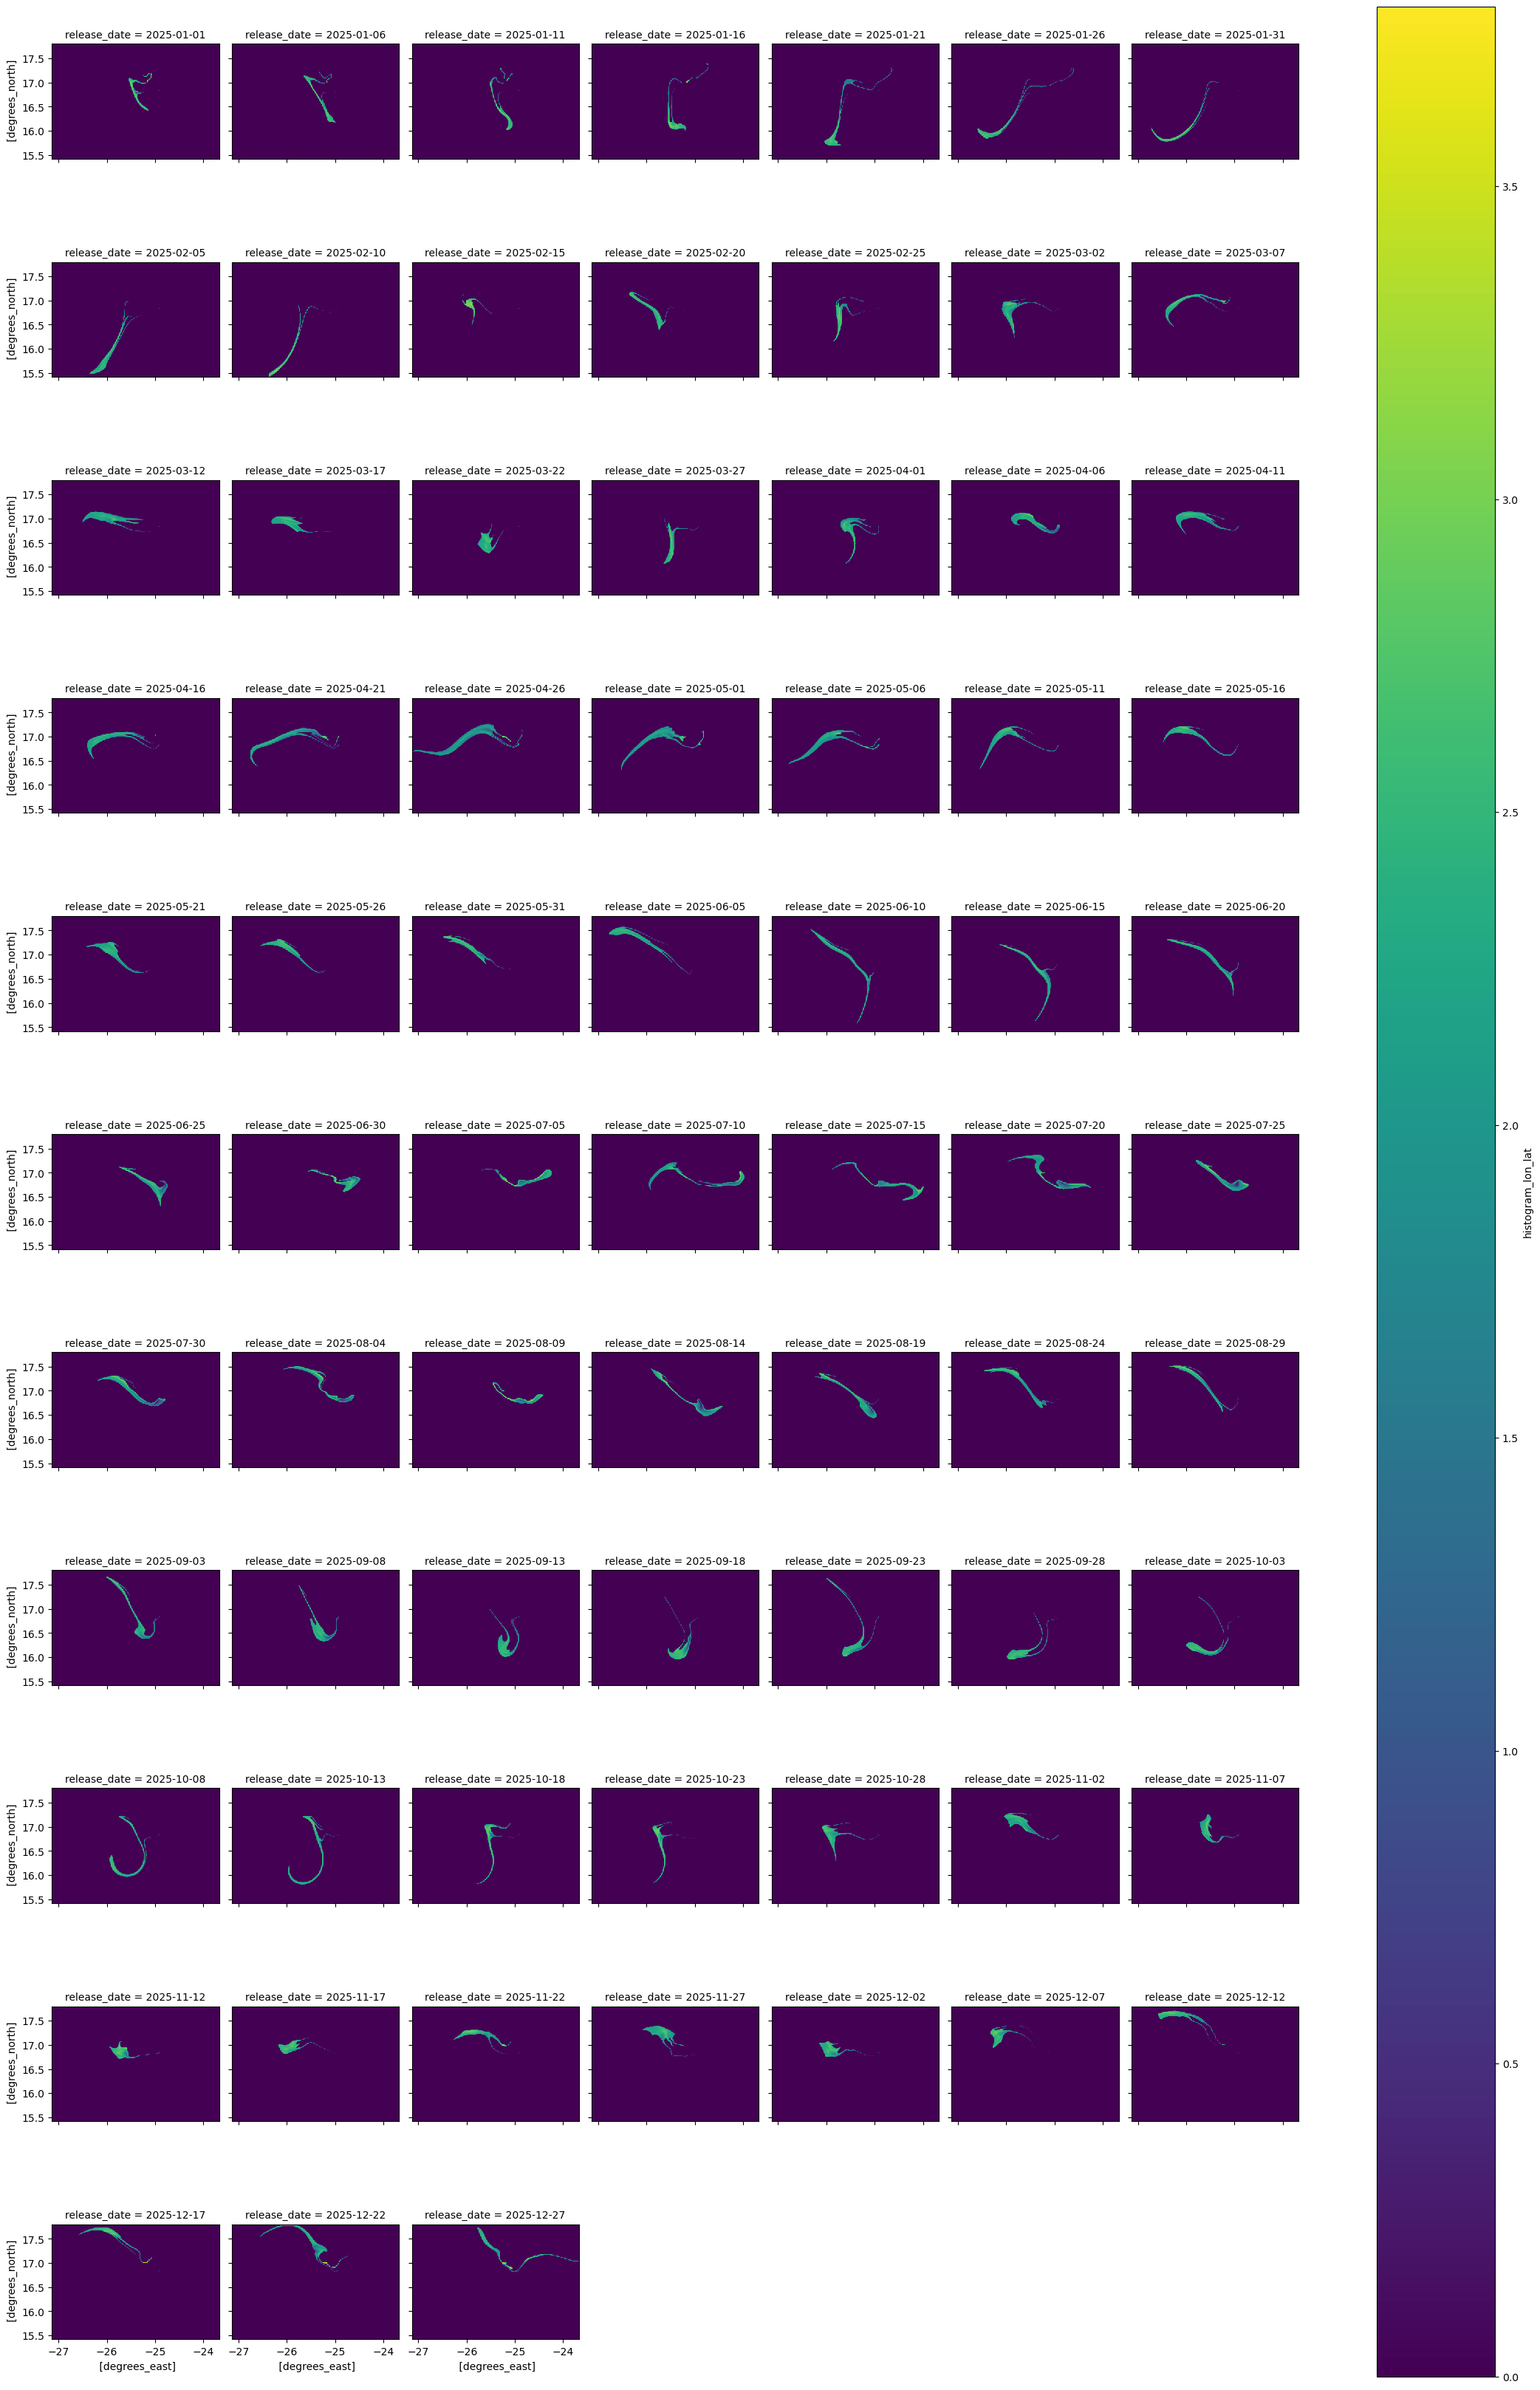

In [7]:
da_final = ds_heatmap_2025.histogram_lon_lat.isel(obs=-1)

fg = np.log10(da_final + 1).plot(
    x="lon", y="lat",
    col="release_date",
    col_wrap=7,
)

for ax in fg.axs.flat:
    ax.set_aspect("equal")

plt.show()